In [36]:
import numpy as np
import matplotlib.pyplot as plt
import math  # Necesario para tu script
from scipy.optimize import differential_evolution
from scipy.constants import (
    k as Boltzmann,
    elementary_charge,
    epsilon_0,
)  # Alias para usar tus nombres
import os


In [37]:
# =============================================================================
# 1. BLOQUE DE CONFIGURACIÓN
# =============================================================================

# Nombre de tu archivo de datos (Columna 1: Voltaje, Columna 2: Corriente)
ARCHIVO_DATOS = "C:/Users/Usuario/Documents/GitHub/RRAM_Simulation/Datos_Experimentales/Ciclos_Experimentales/Cycle_p_12000_pp_set.txt"

# Parámetros Fijos del Sistema
ESPESOR_MUESTRA = 10e-9  # m
T_AMBIENTE = 300 #310.00090159977754  # Kelvin (T0)
R_TERMICA = 10000.0  # K/W (Valor fijo de resistencia térmica)
T_reset = 503 # Temperatura pic del reset

# Configuración del Algoritmo Genético (Límites de búsqueda)
# Formato: (mínimo, máximo)
LIMITES = [
    (0.005, 300.0),  # 1. Epsilon_r (Permitividad relativa)
    (0.001, 2.0),  # 2. Barrera de Potencial (eV)
    (1e-7, 1e-0),  # 3. Factor de Escala (Pre-factor)
]

# =============================================================================
# 2. CONSTANTES FÍSICAS Y MATEMÁTICAS
# =============================================================================

# Constante de Boltzmann en eV/K (~8.617e-5)
K_B_EV = Boltzmann / elementary_charge

In [38]:
def _calcular_beta(epsilon_r: float) -> float:
    """Calcula el factor beta de Poole-Frenkel para una permitividad dada."""
    return math.sqrt(elementary_charge / (epsilon_0 * epsilon_r * math.pi))


def _poole_frenkel_punto(
    V_mag: float,
    T: float,
    beta: float,
    barrier_eV: float,
    scale_factor: float,
) -> tuple[float, float]:
    """
    Calcula corriente y temperatura para un único punto de voltaje.
    T_salida = T_AMBIENTE + P_Joule * R_TERMICA (sin memoria térmica).
    """
    E_field = V_mag / ESPESOR_MUESTRA
    arg = (beta * math.sqrt(E_field) - barrier_eV) / (K_B_EV * T)
    I_sim = scale_factor * E_field * math.exp(arg) * ESPESOR_MUESTRA
    T_nueva = T_AMBIENTE + ((V_mag * I_sim) * R_TERMICA)
    return I_sim, T_nueva


def simular_curva_hrs_subida(
    voltajes: np.ndarray,
    epsilon_r: float,
    barrier_eV: float,
    scale_factor: float,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Tramo HRS de subida: 0 V → V_pico (p.ej. -1.4 V).

    Sin memoria térmica: T_i = T_AMBIENTE + P_i * R_TERMICA.
    Para calcular I_i se necesita T_i, pero T_i depende de I_i → se usa T_{i-1}
    como aproximación del estado térmico al llegar a ese voltaje.
    El primer punto parte de T_AMBIENTE.
    """
    corrientes_out = []
    temperaturas_out = []
    beta = _calcular_beta(epsilon_r)
    T_para_calculo = T_AMBIENTE  # temperatura con la que se evalúa el primer punto

    for v in voltajes:
        V_mag = abs(v)

        if V_mag == 0.0:
            corrientes_out.append(0.0)
            temperaturas_out.append(T_AMBIENTE)
            T_para_calculo = T_AMBIENTE
            continue

        I_sim, T_nueva = _poole_frenkel_punto(V_mag, T_para_calculo, beta, barrier_eV, scale_factor)
        corrientes_out.append(I_sim)
        temperaturas_out.append(T_nueva)
        T_para_calculo = T_nueva  # la T generada por este paso es la entrada del siguiente
        

    return np.array(corrientes_out), np.array(temperaturas_out)


def simular_curva_hrs_bajada(
    voltajes: np.ndarray,
    epsilon_r: float,
    barrier_eV: float,
    scale_factor: float,
    t_pico: float,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Tramo HRS de bajada: V_pico → 0 V (p.ej. -1.4 V → 0 V).

    Sin memoria térmica: T_i = T_AMBIENTE + P_i * R_TERMICA.
    El primer punto parte de t_pico (temperatura real del sistema al llegar al pico),
    que debe obtenerse del último valor de simular_curva_hrs_subida.
    """
    corrientes_out = []
    temperaturas_out = []
    beta = _calcular_beta(epsilon_r)
    T_para_calculo = t_pico  # estado térmico al inicio de la bajada

    for v in voltajes:
        V_mag = abs(v)

        if V_mag == 0.0:
            corrientes_out.append(0.0)
            temperaturas_out.append(T_AMBIENTE)
            # T_para_calculo = T_AMBIENTE
            continue

        I_sim, T_nueva = _poole_frenkel_punto(V_mag, T_para_calculo, beta, barrier_eV, scale_factor)
        corrientes_out.append(I_sim)
        temperaturas_out.append(T_nueva)
        T_para_calculo = T_nueva
        
        # print(f"Voltaje: {v:.3f} V, Corriente Simulada: {I_sim:.5e} A, Temperatura: {T_nueva:.5f}")

    return np.array(corrientes_out), np.array(temperaturas_out)

In [39]:
# =============================================================================
# 3. ALGORITMO GENÉTICO
# =============================================================================

def funcion_costo(genes, v_exp, i_exp_abs, t_inicial):
    eps, phi, scale = genes
    if eps < 1.0 or phi < 0.0 or scale <= 0.0: return 1e99
 
    # Pasamos la temperatura inicial a la simulación
    i_sim, _ = simular_curva_hrs_subida(v_exp, eps, phi, scale)
    
    mask = (i_exp_abs > 1e-25) & (i_sim > 1e-25)
    if np.sum(mask) == 0: return 1e99
    
    return np.sqrt(np.mean((np.log10(i_exp_abs[mask]) - np.log10(i_sim[mask]))**2))

print("Modelo actualizado con Temperatura Inicial.")

def costo_hibrido(genes, v_exp, i_exp_abs):
    eps, phi, scale = genes
    if eps < 1.0 or phi < 0.0 or scale <= 0.0:
        return 1e99

    i_sim, _ = simular_curva_hrs_subida(v_exp, eps, phi, scale)

    mask = (i_exp_abs > 1e-25) & (i_sim > 1e-25)
    if np.sum(mask) < 5:
        return 1e99  # Necesitamos mínimos puntos para derivada

    log_exp = np.log(i_exp_abs[mask])
    log_sim = np.log(i_sim[mask])

    # 1. Error de Magnitud (RMSE clásico)
    mse_val = np.mean((log_exp - log_sim) ** 2)

    # 2. Error de Pendiente (Derivada)
    # Calculamos cómo cambia la corriente respecto al voltaje (la forma de la curva)
    grad_exp = np.gradient(log_exp)
    grad_sim = np.gradient(log_sim)

    mse_grad = np.mean((grad_exp - grad_sim) ** 2)

    # Combinamos ambos errores
    # Le damos mucho peso a la pendiente (x10) para forzar la física correcta
    costo_total = mse_val + (10.0 * mse_grad)

    return costo_total

def new_costo_hibrido(genes, v_exp, i_exp_abs):
    eps, phi, scale = genes
    if eps < 1.0 or phi < 0.0 or scale <= 0.0:
        return 1e99

    i_sim, _ = simular_curva_hrs_subida(v_exp, eps, phi, scale)

    mask = (i_exp_abs > 1e-25) & (i_sim > 1e-25)
    if np.sum(mask) < 5:
        return 1e99

    log_exp = np.log10(i_exp_abs[mask])
    log_sim = np.log10(i_sim[mask])

    # Pesos: favorecen valores pequeños
    pesos = 1.0 / (np.abs(log_exp) + 1e-3)
    pesos /= np.sum(pesos)

    # 1. Error de magnitud ponderado
    mse_val = np.sum(pesos * (log_exp - log_sim) ** 2)

    # 2. Error de pendiente (igual que antes)
    grad_exp = np.gradient(log_exp)
    grad_sim = np.gradient(log_sim)
    mse_grad = np.mean((grad_exp - grad_sim) ** 2)

    return mse_val + 10.0 * mse_grad

Modelo actualizado con Temperatura Inicial.


In [40]:
print("--- AJUSTE CON VALORES INICIALES ---")

# EL archivo de datos txt

ruta_datos = os.path.join(ARCHIVO_DATOS)

print(f"Cargando datos desde: {ruta_datos}")
datos = np.loadtxt(ruta_datos, skiprows=1)

V_exp = datos[:, 0]
I_exp = datos[:, 1]
I_exp_abs = np.abs(I_exp)

V_inicial = V_exp[0]
I_inicial = I_exp_abs[0]

print(f"Voltaje inicial: {V_inicial} V")
print(f"Corriente inicial: {I_inicial:.2e} A")
print(f"Temperatura inicial estimada para el ajuste: {T_AMBIENTE:.3f} K")


--- AJUSTE CON VALORES INICIALES ---
Cargando datos desde: C:/Users/Usuario/Documents/GitHub/RRAM_Simulation/Datos_Experimentales/Ciclos_Experimentales/Cycle_p_12000_pp_set.txt
Voltaje inicial: 0.02 V
Corriente inicial: 8.14e-05 A
Temperatura inicial estimada para el ajuste: 300.000 K


In [41]:
# 2. EJECUTAR AJUSTE
resultado = differential_evolution(
    new_costo_hibrido,
    bounds=LIMITES,
    # Pasamos la T calculada como argumento extra ('args')
    args=(V_exp, I_exp_abs),
    strategy="best1bin",
    popsize=20,
    maxiter=15000,
    disp=True,
)

# 3. RESULTADOS
best_eps, best_phi, best_scale = resultado.x
print("\n" + "=" * 40)
print(f"Epsilon_r: {best_eps:.4f}")
print(f"Barrera:   {best_phi:.4f} eV")
print(f"I_0:    {best_scale:.4e}")
print("=" * 40)

differential_evolution step 1: f(x)= 0.024528477733028263
differential_evolution step 2: f(x)= 0.016917270373674298
differential_evolution step 3: f(x)= 0.01004461408852399
differential_evolution step 4: f(x)= 0.01004461408852399
differential_evolution step 5: f(x)= 0.01004461408852399
differential_evolution step 6: f(x)= 0.01004461408852399
differential_evolution step 7: f(x)= 0.009997565247312386
differential_evolution step 8: f(x)= 0.007612377193593702
differential_evolution step 9: f(x)= 0.007612377193593702
differential_evolution step 10: f(x)= 0.0054820271644819155
differential_evolution step 11: f(x)= 0.0054820271644819155
differential_evolution step 12: f(x)= 0.0054820271644819155
differential_evolution step 13: f(x)= 0.0054820271644819155
differential_evolution step 14: f(x)= 0.0054820271644819155
differential_evolution step 15: f(x)= 0.0030245290751725142
differential_evolution step 16: f(x)= 0.0030245290751725142
differential_evolution step 17: f(x)= 0.0030245290751725142
di

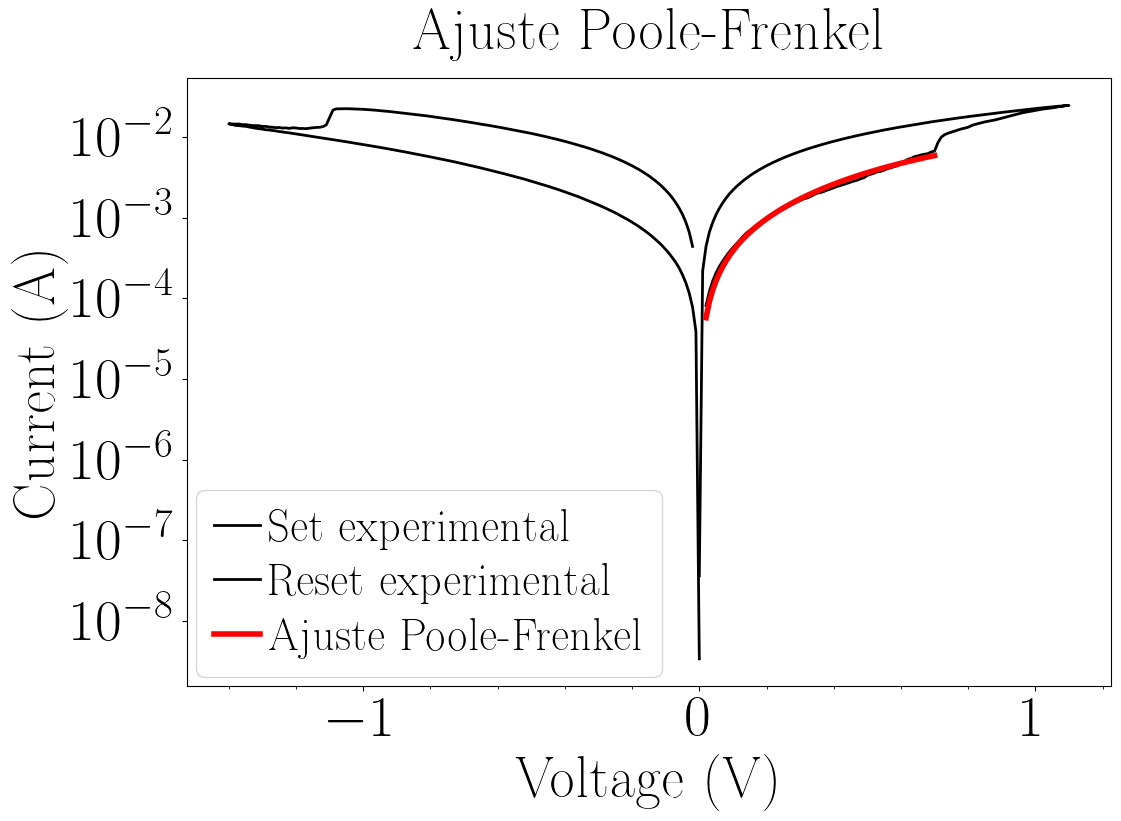

In [42]:
import sys
import os
import matplotlib.ticker as ticker

# 1. CONFIGURACIÓN DEL PATH
# Añadimos la carpeta raíz al path para poder importar el módulo RRAM.
# Esto es necesario porque el notebook está en 'Utilidades' y el módulo en 'RRAM'.
root_path = os.path.abspath(os.path.join(".."))
if root_path not in sys.path:
    sys.path.append(root_path)

# 2. IMPORTACIÓN DESDE REPRESENTATE
from RRAM.Representate import setup_paper_plt, config_ax_IV

# 3. EJECUCIÓN DEL ESTILO
# Aplicamos el estilo de publicación (puedes ajustar el scaling según necesites)
setup_paper_plt(plt, latex=True, scaling=3)

# 4. GRAFICAR RESULTADOS
# Obtenemos la curva simulada con el modelo
I_fit, T_fit = simular_curva_hrs_subida(V_exp, best_eps, best_phi, best_scale)

# Carga de archivos experimentales para el fondo (Set y Reset)
ruta_base = os.path.join(root_path, "RRAM_Simulation","Datos_Experimentales", "Ciclos_Experimentales")
ruta_set = os.path.join(ruta_base, "Cycle_p_12000.txt")
ruta_reset = os.path.join(ruta_base, "Cycle_n_12000.txt")

data_set = np.loadtxt(ruta_set, skiprows=1)
data_reset = np.loadtxt(ruta_reset, skiprows=1)

fig, ax1 = plt.subplots(figsize=(12, 9))

# --- GRÁFICO 1: Curva I-V (Estilo plot_IV) ---
config_ax_IV(ax1)

ax1.set_xlabel("Voltage (V)")
ax1.set_ylabel("Current (A)")
ax1.set_yscale("log")
ax1.set_title("Ajuste Poole-Frenkel", pad=20)

# Formateo de los Ticks del Eje Y
y_ticks = [1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2]
ax1.set_yticks(y_ticks)
ax1.get_yaxis().set_major_formatter(ticker.FormatStrFormatter("$10^{%d}$"))
ax1.set_yticklabels(
    [r"$10^{-9}$", r"$10^{-8}$", r"$10^{-7}$", r"$10^{-6}$", r"$10^{-5}$", r"$10^{-4}$", r"$10^{-3}$", r"$10^{-2}$"]
)

# Curva experimental completa de fondo (Negro)
ax1.plot(data_set[:, 0], np.abs(data_set[:, 1]), color="black", linewidth=2, label="Set experimental")
ax1.plot(data_reset[:, 0], np.abs(data_reset[:, 1]), color="black", linewidth=2, label="Reset experimental")

# Curva de ajuste superpuesta (Rojo grueso)
ax1.plot(V_exp, I_fit, color="red", linewidth=4, label="Ajuste Poole-Frenkel")

ax1.legend(labelspacing=0.3, handletextpad=0.2, handlelength=1.0, borderaxespad=0.2, loc="lower left")

plt.tight_layout()
plt.show()